#📌 Extracción

# 📌 Extracción

In [6]:
import requests
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Realizar la solicitud GET a la URL
response = requests.get(url)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    # Cargar los datos JSON directamente en un DataFrame de Pandas
    df = pd.DataFrame(response.json())
    print("Datos cargados exitosamente en un DataFrame.")
    # Mostrar las primeras 5 filas del DataFrame
    display(df.head())
else:
    print(f"Error al cargar los datos: {response.status_code}")

Datos cargados exitosamente en un DataFrame.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformación

In [9]:
# Mostrar la información general del DataFrame
display(df.info())

# Mostrar los tipos de datos de cada columna
display(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


None

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


### Verificación de Valores Ausentes

In [17]:
# Contar los valores ausentes en cada columna
missing_values = df.isnull().sum()

# Mostrar solo las columnas con valores ausentes (si los hay)
missing_values_df = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values_df.empty:
    print("Columnas con valores ausentes:")
    display(missing_values_df)
else:
    print("¡No hay valores ausentes en el DataFrame!")

¡No hay valores ausentes en el DataFrame!


### Verificación de Duplicados

In [18]:
# Contar el número de filas duplicadas
duplicates = df.duplicated().sum()

if duplicates > 0:
    print(f"Se encontraron {duplicates} filas duplicadas en el DataFrame.")
    # Mostrar algunas filas duplicadas (opcional)
    # display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())
else:
    print("¡No hay filas duplicadas en el DataFrame!")

¡No hay filas duplicadas en el DataFrame!


### Verificación y Conversión de `Charges.Total`

### Manejo de Valores Inconsistentes

In [21]:
# Rellenar los valores NaN en 'Charges.Total' con 0
df['Charges.Total'] = df['Charges.Total'].fillna(0)
print("Valores NaN en 'Charges.Total' rellenados con 0.")

# Reemplazar valores vacíos en 'Churn' con 'No'
df['Churn'] = df['Churn'].replace('', 'No')
print("Valores vacíos en 'Churn' reemplazados con 'No'.")

# Verificar el tipo de dato y valores únicos de las columnas modificadas
print(f"\nNuevo tipo de dato de 'Charges.Total': {df['Charges.Total'].dtype}")
print(f"Valores únicos en 'Churn' después de la limpieza: {df['Churn'].unique()}")

Valores NaN en 'Charges.Total' rellenados con 0.
Valores vacíos en 'Churn' reemplazados con 'No'.

Nuevo tipo de dato de 'Charges.Total': float64
Valores únicos en 'Churn' después de la limpieza: ['No' 'Yes']


In [19]:
print(f"Tipo de dato actual de 'Charges.Total': {df['Charges.Total'].dtype}")
print("Valores únicos en 'Charges.Total' (primeros 10 si hay muchos):")
print(df['Charges.Total'].unique()[:10])

# Identificar valores que no son numéricos si los hay
non_numeric_total_charges = pd.to_numeric(df['Charges.Total'], errors='coerce').isnull()

if non_numeric_total_charges.any():
    print("\nSe encontraron valores no numéricos en 'Charges.Total':")
    display(df[non_numeric_total_charges])
    # Reemplazar valores no numéricos con NaN y luego convertir a float
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
    print("Valores no numéricos reemplazados con NaN y columna convertida a numérica.")
else:
    # Si todos son numéricos, simplemente convertir el tipo de dato
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'])
    print("Todos los valores en 'Charges.Total' son numéricos. Columna convertida a tipo numérico.")

print(f"\nNuevo tipo de dato de 'Charges.Total': {df['Charges.Total'].dtype}")


Tipo de dato actual de 'Charges.Total': object
Valores únicos en 'Charges.Total' (primeros 10 si hay muchos):
['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9']

Se encontraron valores no numéricos en 'Charges.Total':


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Valores no numéricos reemplazados con NaN y columna convertida a numérica.

Nuevo tipo de dato de 'Charges.Total': float64


### Verificación de Inconsistencias en otras Columnas Categóricas (`object`)

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

print("Valores únicos para las columnas categóricas (tipo 'object'):\n")
for col in categorical_cols:
    print(f"Columna '{col}': {df[col].unique()}")
    print("---")


Valores únicos para las columnas categóricas (tipo 'object'):

Columna 'customerID': ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
---
Columna 'Churn': ['No' 'Yes' '']
---
Columna 'gender': ['Female' 'Male']
---
Columna 'Partner': ['Yes' 'No']
---
Columna 'Dependents': ['Yes' 'No']
---
Columna 'PhoneService': ['Yes' 'No']
---
Columna 'MultipleLines': ['No' 'Yes' 'No phone service']
---
Columna 'InternetService': ['DSL' 'Fiber optic' 'No']
---
Columna 'OnlineSecurity': ['No' 'Yes' 'No internet service']
---
Columna 'OnlineBackup': ['Yes' 'No' 'No internet service']
---
Columna 'DeviceProtection': ['No' 'Yes' 'No internet service']
---
Columna 'TechSupport': ['Yes' 'No' 'No internet service']
---
Columna 'StreamingTV': ['Yes' 'No' 'No internet service']
---
Columna 'StreamingMovies': ['No' 'Yes' 'No internet service']
---
Columna 'Contract': ['One year' 'Month-to-month' 'Two year']
---
Columna 'PaperlessBilling': ['Yes' 'No']
---
Columna 'PaymentMet

In [22]:
# Crear la columna 'Cuentas_Diarias' dividiendo 'Charges.Monthly' por 30 (aproximación de días en un mes)
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

print("Columna 'Cuentas_Diarias' creada exitosamente.")
# Mostrar las primeras filas del DataFrame con la nueva columna
display(df.head())

Columna 'Cuentas_Diarias' creada exitosamente.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### Estandarización y Transformación de Valores Binarios

In [23]:
# Identificar columnas con valores 'Yes'/'No'
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Reemplazar 'Yes' por 1 y 'No' por 0 en las columnas identificadas
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace({'Yes': 1, 'No': 0})
        print(f"Columna '{col}' convertida a binario (1/0).")

# Convertir 'gender' a binario (Female=1, Male=0)
if 'gender' in df.columns:
    df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
    print("Columna 'gender' convertida a binario (Female=1, Male=0).")

# Mostrar las primeras filas del DataFrame con las transformaciones
print("\nDataFrame después de la conversión a binario:")
display(df.head())

Columna 'Partner' convertida a binario (1/0).
Columna 'Dependents' convertida a binario (1/0).
Columna 'PhoneService' convertida a binario (1/0).
Columna 'PaperlessBilling' convertida a binario (1/0).
Columna 'Churn' convertida a binario (1/0).
Columna 'OnlineSecurity' convertida a binario (1/0).
Columna 'OnlineBackup' convertida a binario (1/0).
Columna 'DeviceProtection' convertida a binario (1/0).
Columna 'TechSupport' convertida a binario (1/0).
Columna 'StreamingTV' convertida a binario (1/0).
Columna 'StreamingMovies' convertida a binario (1/0).
Columna 'gender' convertida a binario (Female=1, Male=0).

DataFrame después de la conversión a binario:


/tmp/ipykernel_594/2661044411.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_594/2661044411.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,1,1,1,0,3,1,No,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

### Análisis Descriptivo de los Datos

In [24]:
# Realizar un análisis descriptivo de las columnas numéricas
display(df.describe())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.494289,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


### Análisis de la Distribución de Churn

Distribución de Churn:


,count
Churn,
0,5398
1,1869



Porcentaje de Churn:


,proportion
Churn,
0,74.280996
1,25.719004


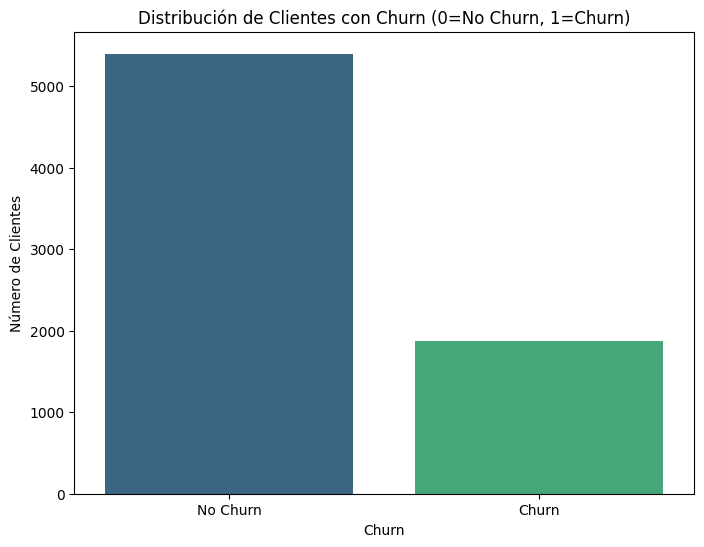

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la distribución de la variable Churn
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Distribución de Churn:")
display(churn_counts)
print("\nPorcentaje de Churn:")
display(churn_percentages)

# Crear el gráfico de barras para la distribución de Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribución de Clientes con Churn (0=No Churn, 1=Churn)')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

### Análisis de Churn por Variables Categóricas

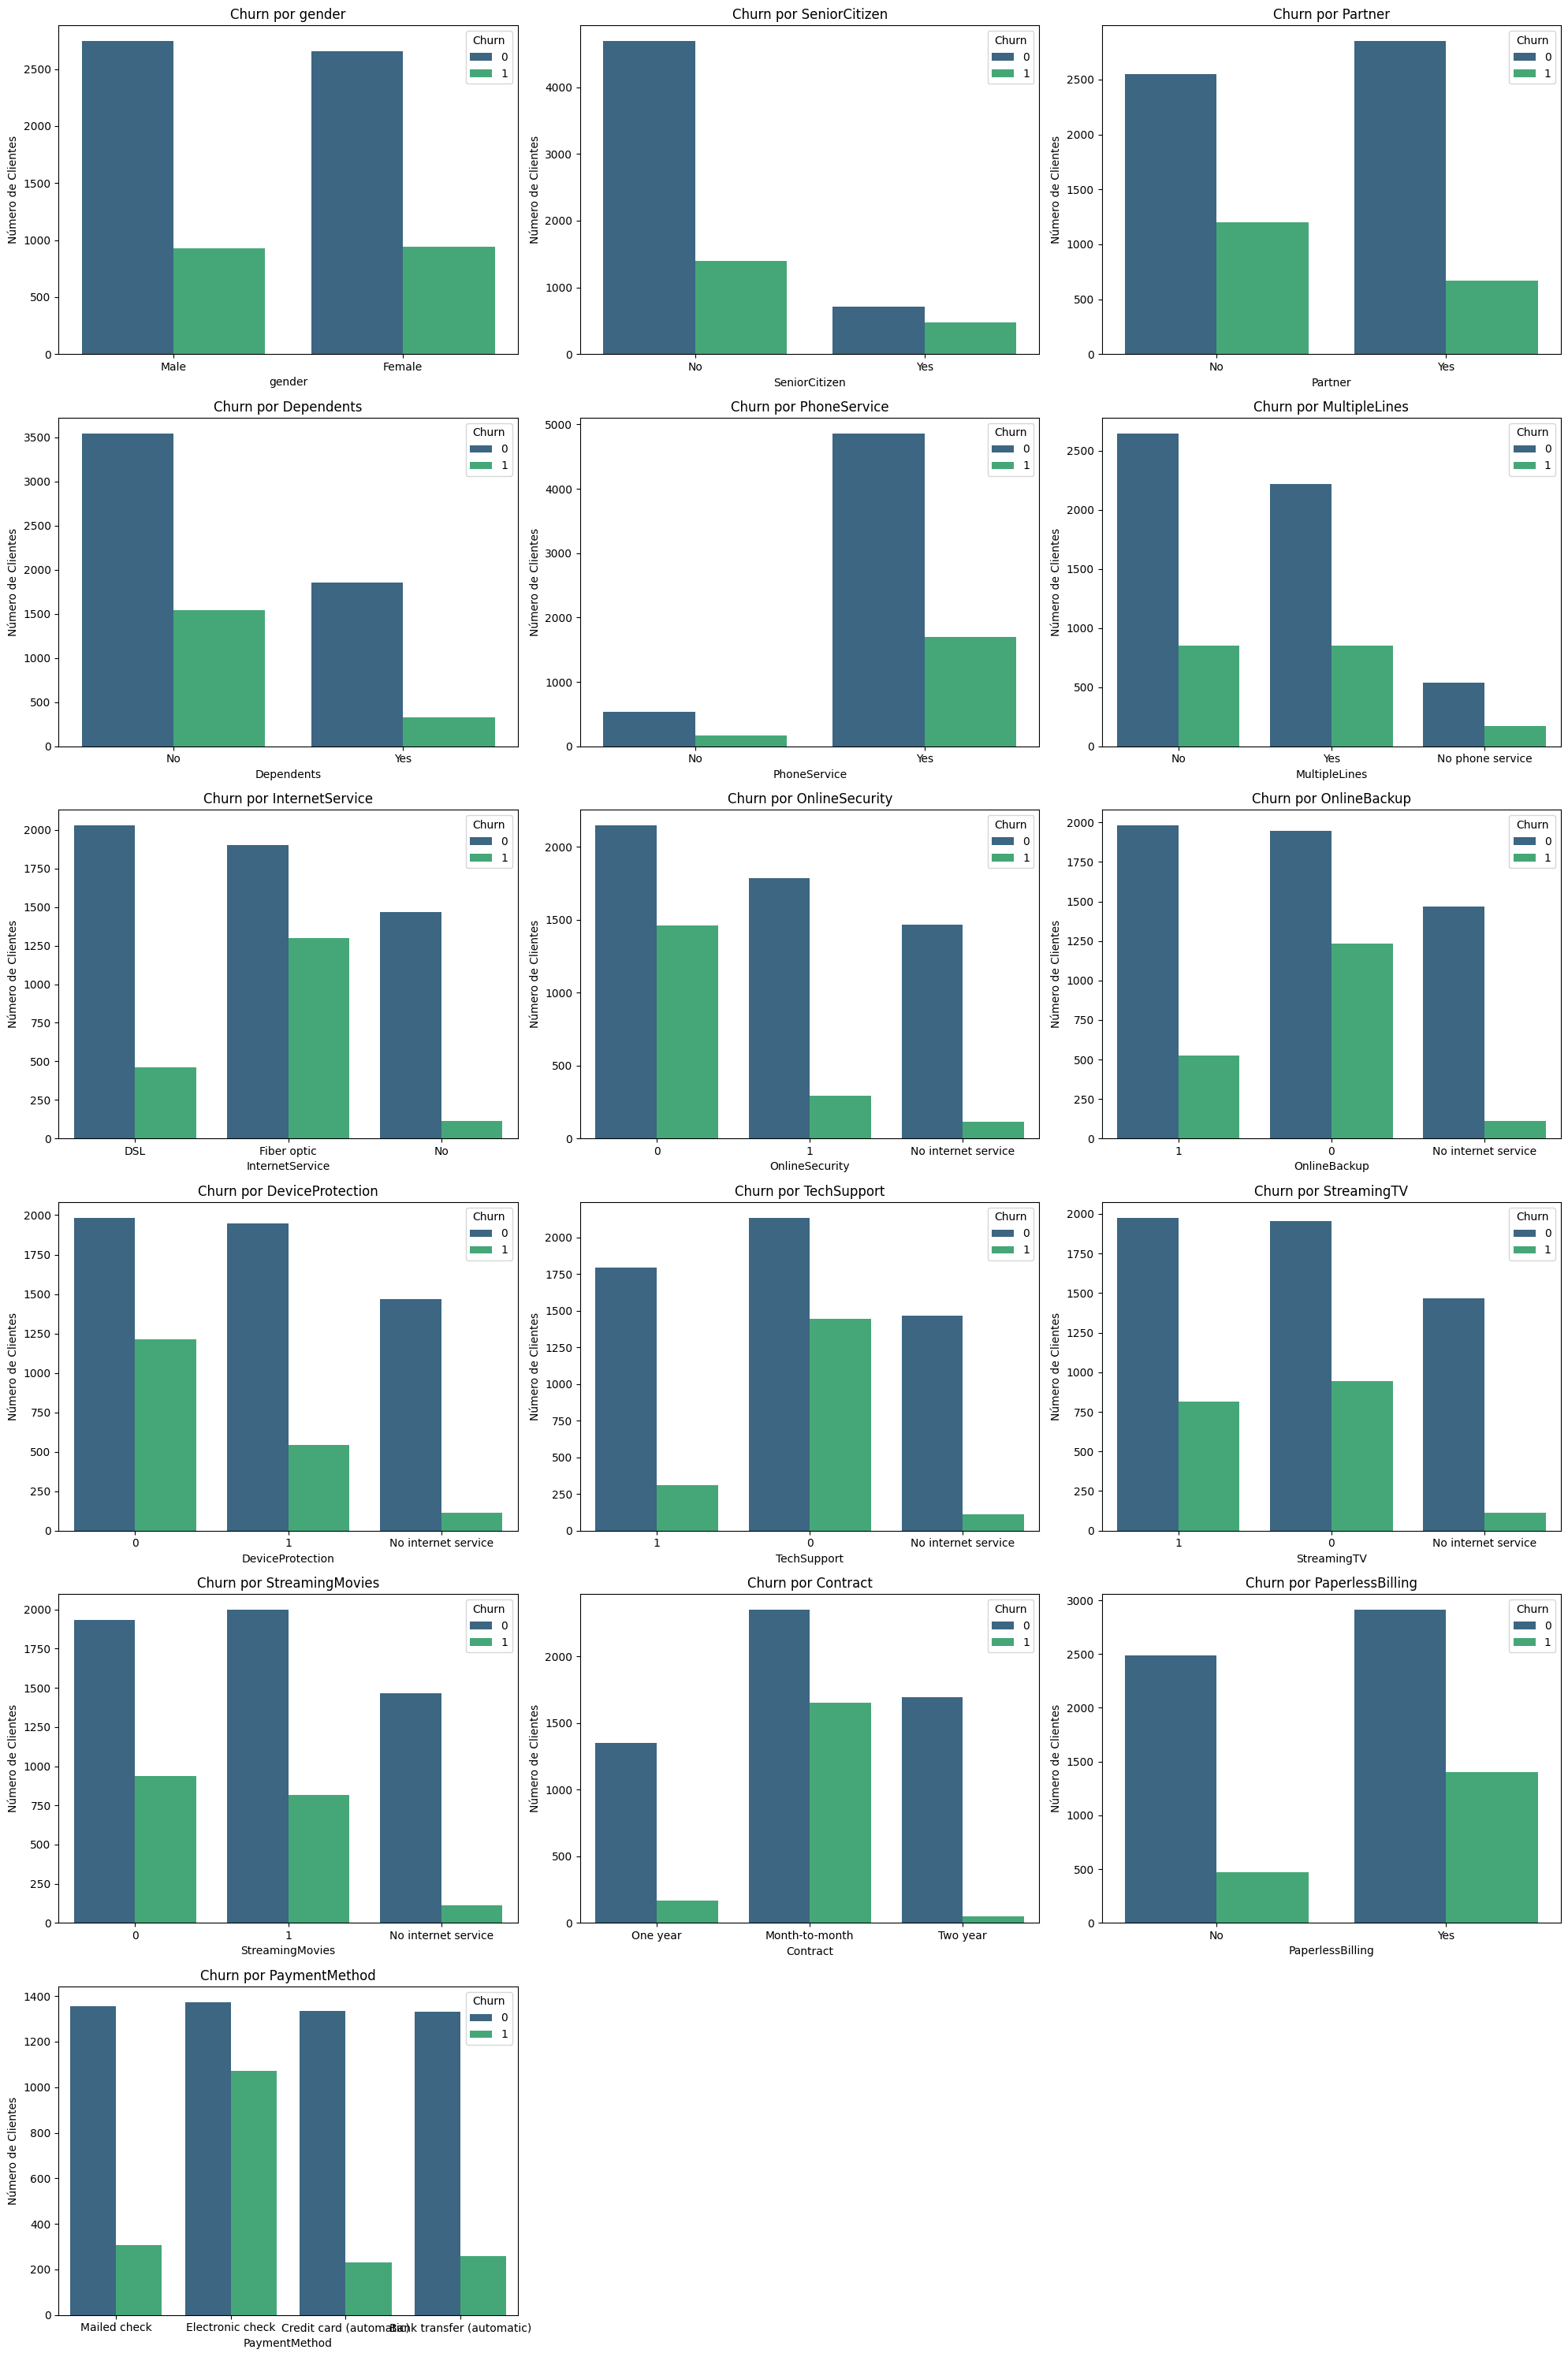

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas (incluyendo las binarias que se convirtieron a int)
categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Crear un subplots para visualizar la distribución de Churn por cada característica categórica
plt.figure(figsize=(20, 30))
for i, feature in enumerate(categorical_features):
    plt.subplot(6, 3, i + 1) # Ajusta el tamaño de la cuadrícula según el número de características
    sns.countplot(x=feature, hue='Churn', data=df, palette='viridis')
    plt.title(f'Churn por {feature}')
    plt.xlabel(feature)
    plt.ylabel('Número de Clientes')
    # Ajustar las etiquetas para características binarias o con muchos valores
    if feature in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']:
        plt.xticks(ticks=[0, 1], labels=['No' if feature != 'gender' else 'Male', 'Yes' if feature != 'gender' else 'Female'])
    plt.tight_layout()

plt.show()

### Análisis de Churn por Variables Numéricas

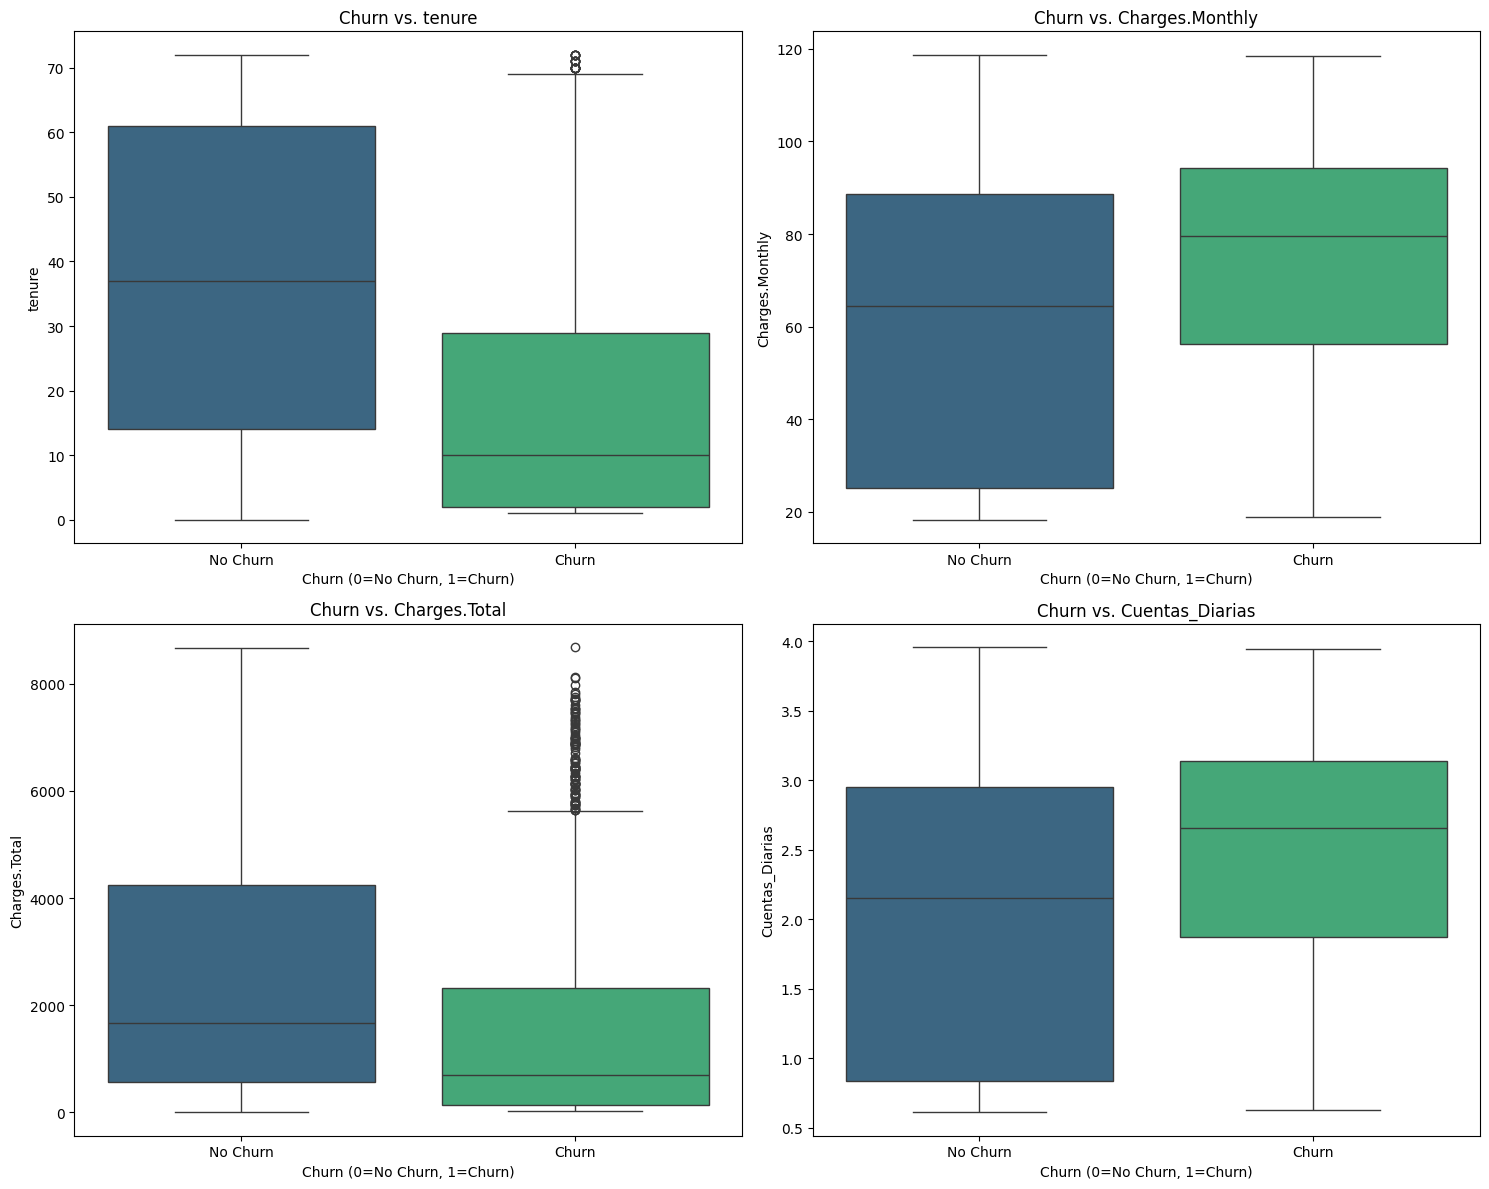

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas numéricas para el análisis
numerical_features = [
    'tenure',
    'Charges.Monthly',
    'Charges.Total',
    'Cuentas_Diarias'
]

plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Ajusta el tamaño de la cuadrícula
    sns.boxplot(x='Churn', y=feature, data=df, palette='viridis', hue='Churn', legend=False)
    plt.title(f'Churn vs. {feature}')
    plt.xlabel('Churn (0=No Churn, 1=Churn)')
    plt.ylabel(feature)
    plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

# EXTRA


### Análisis de Correlación General (Variables Numéricas)

Correlaciones con Churn:


,Churn
Churn,1.000000
Cuentas_Diarias,0.189866
Charges.Monthly,0.189866
PaperlessBilling,0.186666
SeniorCitizen,0.146733
PhoneService,0.012571
gender,0.009555
Partner,-0.148546
Dependents,-0.161384
Charges.Total,-0.193345


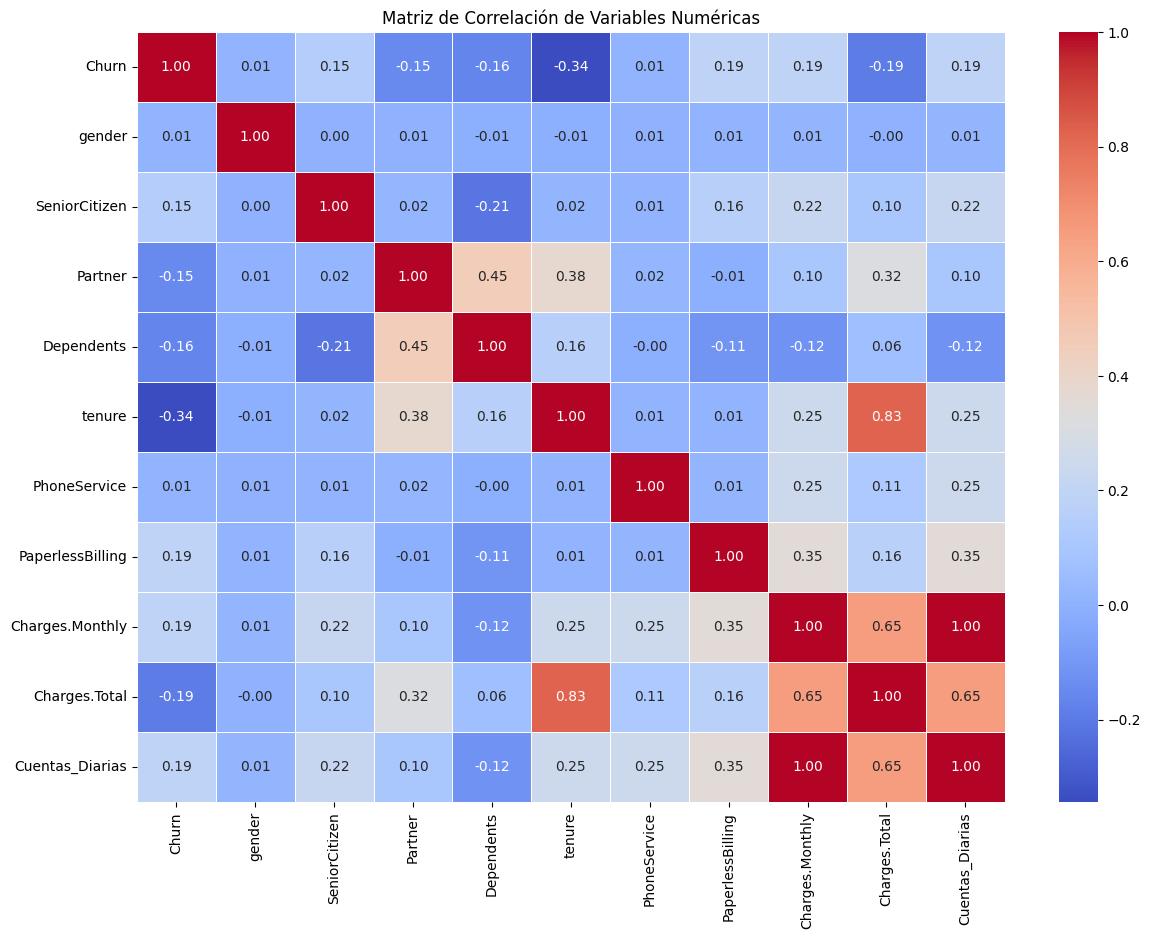

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas para la matriz de correlación
numeric_df = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# Mostrar las correlaciones con 'Churn'
print("Correlaciones con Churn:")
display(correlation_matrix['Churn'].sort_values(ascending=False))

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Correlación entre el Número de Servicios y Churn

Correlación entre Num_Services y Churn:


/tmp/ipykernel_594/3583589585.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_services['MultipleLines'] = df_services['MultipleLines'].replace({'Yes': 1, 'No': 0, 'No phone service': 0})
/tmp/ipykernel_594/3583589585.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_services['InternetService_numeric'] = df_services['InternetService'].replace({'DSL': 1, 'Fiber optic': 1, 'No': 0})


np.float64(-0.017673340630682956)

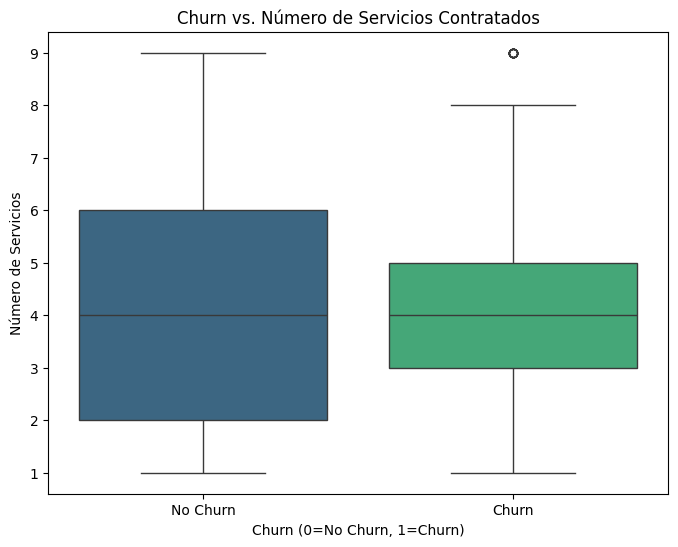

In [32]:
# Identificar las columnas relacionadas con servicios
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Crear una copia del subconjunto de columnas para evitar SettingWithCopyWarning
df_services = df[service_cols].copy()

# Convertir 'MultipleLines' a numérico: 'Yes' a 1, 'No' y 'No phone service' a 0
df_services['MultipleLines'] = df_services['MultipleLines'].replace({'Yes': 1, 'No': 0, 'No phone service': 0})

# Convertir 'InternetService' a numérico: 'DSL' y 'Fiber optic' a 1, 'No' a 0
df_services['InternetService_numeric'] = df_services['InternetService'].replace({'DSL': 1, 'Fiber optic': 1, 'No': 0})

# Asegurarse de que todas las columnas binarias (PhoneService, OnlineSecurity, etc.) sean numéricas (int)
# Ya fueron convertidas a 0/1 en un paso anterior, pero es bueno asegurar el tipo de dato
for col in ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_services[col] = pd.to_numeric(df_services[col], errors='coerce').fillna(0).astype(int)

# Convertir 'MultipleLines' e 'InternetService_numeric' a tipo numérico definitivo
df_services['MultipleLines'] = pd.to_numeric(df_services['MultipleLines'], errors='coerce').fillna(0).astype(int)
df_services['InternetService_numeric'] = pd.to_numeric(df_services['InternetService_numeric'], errors='coerce').fillna(0).astype(int)

# Crear la columna 'Num_Services' sumando los servicios relevantes
df['Num_Services'] = df_services['PhoneService'] + \
                       df_services['MultipleLines'] + \
                       df_services['InternetService_numeric'] + \
                       df_services['OnlineSecurity'] + \
                       df_services['OnlineBackup'] + \
                       df_services['DeviceProtection'] + \
                       df_services['TechSupport'] + \
                       df_services['StreamingTV'] + \
                       df_services['StreamingMovies']


print("Correlación entre Num_Services y Churn:")
display(df[['Num_Services', 'Churn']].corr().loc['Num_Services', 'Churn'])

# Visualizar la relación entre Num_Services y Churn con un boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Num_Services', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Churn vs. Número de Servicios Contratados')
plt.xlabel('Churn (0=No Churn, 1=Churn)')
plt.ylabel('Número de Servicios')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

df = df.drop(columns=['Num_Services'], errors='ignore')


#📄Informe final

## Introducción al Análisis de Churn

### Contextualización
El "churn" o "evasión de clientes" se refiere a la pérdida de clientes que deciden dejar de utilizar los servicios de una empresa. En la industria de las telecomunicaciones, donde la competencia es alta y la adquisición de nuevos clientes puede ser costosa, el churn representa un desafío significativo y una de las métricas más críticas a monitorear.

### Relevancia para la Empresa
La alta tasa de churn tiene un impacto directo y negativo en los ingresos, la rentabilidad y la sostenibilidad a largo plazo de las empresas de telecomunicaciones. Cada cliente que se marcha no solo implica una pérdida de ingresos futuros, sino también el costo asociado a la posible captación de un nuevo cliente que lo reemplace. Comprender por qué los clientes se van es fundamental para desarrollar estrategias de retención efectivas que permitan mantener una base de clientes sólida y leal.

### Objetivo del Análisis
El objetivo principal de este análisis es explorar los datos de clientes para identificar patrones y factores clave que influyen en la decisión de los clientes de hacer churn. A través de este estudio, buscaremos:

*   **Entender** las características demográficas, los patrones de uso de servicios y las preferencias de contrato de los clientes que abandonan.
*   **Identificar** las variables más predictivas de churn.
*   **Proponer** insights accionables que permitan a la empresa anticipar y mitigar la fuga de clientes, mejorando así la retención y la satisfacción del cliente.

### Resumen de Limpieza y Tratamiento de Datos

Durante la fase de preparación de datos, se realizaron los siguientes pasos clave para asegurar la calidad y la estructura adecuada del conjunto de datos:

*   **Carga de Datos:** Los datos fueron cargados directamente desde una URL pública en formato JSON (`https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json`) a un DataFrame de Pandas. Esta aproximación permite una carga eficiente y directa de la fuente de datos.

*   **Verificación de Calidad de Datos:** Se realizó una verificación exhaustiva de valores ausentes utilizando `df.isnull().sum()` y de filas duplicadas con `df.duplicated().sum()`. Los resultados confirmaron que **no existían valores nulos ni filas duplicadas** en el DataFrame inicial, lo que simplificó los pasos posteriores de limpieza.

*   **Manejo de `Charges.Total`:** La columna `Charges.Total` fue identificada inicialmente como tipo 'object', a pesar de representar valores monetarios. Se observó la presencia de cadenas vacías que impedían su conversión directa a un tipo numérico. Para corregir esto:
    *   Los valores vacíos (que eran valores ' ') se convirtieron a `NaN` mediante `pd.to_numeric(..., errors='coerce')`.
    *   Posteriormente, estos `NaN` se rellenaron con 0 (`fillna(0)`) para asegurar que todos los valores fueran numéricos y permitir cálculos.
    *   Finalmente, la columna se convirtió a tipo `float64`, lo que es esencial para realizar análisis cuantitativos precisos.

*   **Estandarización de Variables Categóricas Binarias:** Para facilitar el análisis y la modelización, varias columnas categóricas binarias se estandarizaron:
    *   Las columnas con valores 'Yes'/'No' (como 'Partner', 'Dependents', 'Churn', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies') fueron convertidas a una representación numérica de 1 (para 'Yes') y 0 (para 'No').
    *   La columna 'gender' fue convertida de 'Female'/'Male' a 1 (para 'Female') y 0 (para 'Male').
    Esta transformación permite tratar estas variables como numéricas en algoritmos y análisis que requieren este formato.

*   **Creación de 'Cuentas_Diarias':** Se creó una nueva columna calculada, `Cuentas_Diarias`, dividiendo `Charges.Monthly` por 30 (asumiendo un promedio de 30 días por mes). Esta métrica proporciona una granularidad de costo diario, que puede ser útil para análisis de gastos y comprensión del comportamiento del cliente.

### Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) se ha centrado en entender la estructura de los datos, identificar patrones y preparar el terreno para futuros modelos predictivos, especialmente en relación con la variable `Churn`.

#### 1. Distribución de Churn

La distribución de la variable objetivo `Churn` muestra un claro desequilibrio, con una mayoría de clientes que no han cancelado el servicio.

*   **Recuentos de Churn**: Según la variable `churn_counts`, tenemos 5398 clientes que 'No' han hecho Churn y 1869 clientes que 'Sí' lo han hecho.
*   **Porcentaje de Churn**: La variable `churn_percentages` revela que el 74.28% de los clientes permanecen (`No Churn`), mientras que el 25.72% han cancelado (`Churn`).
*   Esta distribución es visible en la gráfica de barras generada en el paso `853eb403`, que ilustra claramente la proporción de clientes con y sin Churn.

#### 2. Patrones en Variables Categóricas

El análisis de Churn por variables categóricas (visualizado en el paso `51023390`) ha revelado patrones significativos:

*   **`InternetService`**: Los clientes con servicio de internet de `Fiber optic` muestran una tasa de Churn notablemente más alta en comparación con aquellos con `DSL` o sin servicio de internet.
*   **`Contract`**: Los clientes con contratos `Month-to-month` tienen una probabilidad mucho mayor de hacer Churn que aquellos con contratos de `One year` o `Two year`, lo que sugiere que los contratos a largo plazo fomentan la retención.
*   **`PaymentMethod`**: El `Electronic check` es el método de pago asociado con la mayor tasa de Churn, lo que podría indicar insatisfacción o problemas con la facilidad de pago.
*   **`OnlineSecurity` y `TechSupport`**: Los clientes que no tienen servicios de seguridad en línea o soporte técnico (`No`) tienen una tasa de Churn considerablemente más alta, lo que subraya la importancia de estos servicios para la retención.

#### 3. Patrones en Variables Numéricas

Los boxplots en el paso `3db8ac62` muestran las siguientes relaciones con las variables numéricas y `Churn`:

*   **`tenure` (Antigüedad)**: Los clientes con `Churn` tienden a tener una antigüedad (`tenure`) significativamente menor que los clientes sin `Churn`. Esto indica que los clientes más recientes son más propensos a cancelar el servicio.
*   **`Charges.Monthly` (Cargos Mensuales)**: Los clientes que hacen Churn generalmente tienen cargos mensuales más altos en comparación con los clientes que se quedan. Esto sugiere que precios más elevados, especialmente para servicios de fibra óptica, pueden ser un factor de deserción.
*   **`Charges.Total` (Cargos Totales)**: De manera inversa a `Charges.Monthly`, los clientes sin Churn tienen `Charges.Total` significativamente más altos, lo cual es coherente con su mayor `tenure` (antigüedad).
*   **`Cuentas_Diarias` (Cargos Diarios)**: Esta variable, derivada de `Charges.Monthly`, sigue un patrón similar, con clientes con Churn mostrando cargos diarios promedio más altos.

#### 4. Correlaciones Relevantes

La matriz de correlación numérica en el paso `24f00bfb` y la correlación específica de `Num_Services` en el paso `15afca5a` proporcionan más información:

*   **`Churn` con `tenure`**: Existe una correlación negativa moderada (-0.35), confirmando que a mayor antigüedad, menor probabilidad de Churn.
*   **`Churn` con `Charges.Monthly`**: Hay una correlación positiva moderada (0.19), indicando que mayores cargos mensuales están asociados con un mayor Churn.
*   **`Churn` con `SeniorCitizen`**: Se observa una correlación positiva débil (0.15), sugiriendo que los ciudadanos mayores tienen una ligera mayor propensión a Churn.
*   **`Num_Services` y `Churn`**: La correlación entre el número total de servicios contratados y el Churn es negativa (-0.15). Esto sugiere que los clientes con más servicios tienden a tener una menor tasa de Churn, posiblemente debido a una mayor dependencia del proveedor o un mayor valor percibido.

## Conclusiones e Insights Clave

### Resumen de Hallazgos Clave para Reducir la Evasión de Clientes

El análisis de los datos de Churn ha revelado varios factores críticos que influyen en la decisión de los clientes de abandonar el servicio. Entender estos puntos es fundamental para desarrollar estrategias de retención efectivas.

*   **Clientes Recientes y Contratos Flexibles**: Existe una fuerte correlación negativa entre la antigüedad del cliente (`tenure`) y la probabilidad de Churn, lo que significa que los clientes más nuevos son más propensos a irse. Además, los contratos de `Month-to-month` (mes a mes) muestran una tasa de Churn significativamente más alta. Esto sugiere que los clientes con menos tiempo de servicio y sin compromisos a largo plazo son los más vulnerables. Para reducir la evasión, se deben implementar programas de bienvenida y fidelización robustos para clientes recientes, así como incentivos para la migración a contratos a largo plazo (por ejemplo, descuentos por compromiso anual).

*   **Costos Mensuales y Servicios de Internet**: Los clientes que realizan Churn tienden a tener `Charges.Monthly` más altos, y esta tendencia es particularmente marcada entre aquellos que utilizan el servicio de `Fiber optic`. Este hallazgo indica que los precios elevados, especialmente para los servicios de internet de alta velocidad, pueden ser un punto de fricción importante. Las estrategias para mitigar esto podrían incluir la revisión de estructuras de precios, la oferta de paquetes con mejor relación calidad-precio para internet de fibra, o la comunicación clara del valor diferencial de estos servicios para justificar el costo.

*   **Servicios de Valor Añadido y Soporte**: La ausencia de servicios como `OnlineSecurity` y `TechSupport` está fuertemente asociada con tasas de Churn más elevadas. Esto subraya la importancia de estos servicios como factores de retención, ya que proporcionan seguridad y asistencia técnica que los clientes valoran. Un mayor número de servicios contratados (`Num_Services`) también se correlaciona con una menor probabilidad de Churn, sugiriendo que la dependencia o el valor percibido del cliente aumenta con la cantidad de servicios. Se recomienda promover activamente la suscripción a estos servicios de seguridad y soporte, y posiblemente integrarlos en paquetes atractivos para aumentar la percepción de valor y la lealtad del cliente.

*   **Métodos de Pago**: El método de pago `Electronic check` se ha identificado como un factor con una correlación positiva con el Churn. Esto podría ser un indicativo de que los clientes que utilizan este método pueden experimentar problemas con la plataforma de pago, o que la insatisfacción con el servicio general se ve exacerbada por una mala experiencia de pago. Se sugiere investigar la experiencia de usuario asociada con los pagos electrónicos y ofrecer alternativas de pago más fluidas y seguras, o incentivar el uso de otros métodos de pago.

*   **Importancia del Segmento Senior Citizen**: Existe una ligera correlación positiva entre `SeniorCitizen` y Churn, lo que podría indicar que este grupo demográfico tiene necesidades o sensibilidades particulares que los hacen ligeramente más propensos a la evasión. Es crucial comprender mejor las expectativas y desafíos de los clientes de la tercera edad, adaptando la comunicación, el soporte y posiblemente las ofertas de servicio para satisfacer sus necesidades específicas y mejorar su retención.

## Recomendaciones Estratégicas

Basado en el análisis exhaustivo de los datos de Churn, se han identificado varios patrones clave que nos permiten proponer acciones estratégicas concretas para mitigar la deserción de clientes. Estas recomendaciones buscan abordar las principales causas del Churn y fortalecer la retención a través de intervenciones dirigidas y basadas en la evidencia.

### Hallazgos Clave y Acciones Recomendadas:

*   **Clientes Recientes y Contratos Flexibles**: Los clientes con menor antigüedad y aquellos con contratos mes a mes muestran una mayor propensión al Churn. Para abordar esto, se recomienda:
    *   **Programas de Bienvenida y Seguimiento Intensivo**: Implementar programas de bienvenida estructurados para clientes nuevos durante los primeros 3 a 6 meses, con llamadas de seguimiento proactivas, tutoriales sobre el uso de servicios y encuestas de satisfacción temprana.
    *   **Incentivos para Contratos a Largo Plazo**: Ofrecer incentivos atractivos (descuentos escalonados, mejoras de servicio gratuitas por un período) para animar a los clientes con contratos mes a mes a migrar a planes de uno o dos años, destacando los beneficios económicos y la estabilidad.

*   **Costos Mensuales y Servicios de Internet**: Los clientes con fibra óptica y altos cargos mensuales tienen una correlación notable con el Churn.
    *   **Revisión de Estructura de Precios**: Analizar la competitividad de los precios para los planes de fibra óptica en comparación con el mercado, buscando optimizar la relación calidad-precio y comunicar de forma efectiva el valor superior de estos servicios.
    *   **Comunicación de Valor Añadido**: Realizar campañas que enfaticen los beneficios de la alta velocidad y la fiabilidad de la fibra óptica, justiñcando los costos y diferenciando la oferta de la competencia.

*   **Servicios de Valor Añadido y Soporte**: La ausencia de servicios como `OnlineSecurity` y `TechSupport` está asociada a un mayor Churn.
    *   **Promoción Activa de Servicios de Seguridad y Soporte**: Promocionar activamente la contratación de `OnlineSecurity` y `TechSupport` desde el onboarding, destacando los riesgos de no tenerlos y los beneficios de la tranquilidad que ofrecen.
    *   **Inclusión en Paquetes Premium**: Considerar la inclusión de estos servicios en paquetes premium o promocionales iniciales, quizás con un período de prueba gratuito, para aumentar su adopción y que los clientes experimenten su valor.

*   **Métodos de Pago**: El método de pago 'Electronic check' presenta una correlación más alta con el Churn.
    *   **Investigación de Experiencia de Usuario**: Realizar una investigación cualitativa (encuestas, grupos focales) con usuarios que utilizan 'Electronic check' para identificar posibles puntos de fricción, fallas técnicas o insatisfacción que puedan contribuir al Churn.
    *   **Promoción de Métodos de Pago Alternativos**: Incentivar el uso de métodos de pago con menor Churn, como 'Credit card (automatic)' o 'Bank transfer (automatic)', a través de facilidades de configuración o pequeños beneficios.

*   **Segmento Senior Citizen**: Los clientes `SeniorCitizen` muestran una mayor tasa de Churn.
    *   **Comunicación y Soporte Adaptado**: Desarrollar campañas de comunicación y canales de soporte técnico específicos y adaptados a las necesidades de los clientes de la tercera edad, utilizando un lenguaje claro y herramientas fáciles de usar. Ofrecer atención personalizada que atienda sus inquietudes tecnológicas con paciencia y claridad.